In [194]:
import time
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar,DataLoader

from network.layer import Layer,WriteConfig

import math

In [195]:
chip=CHIP(PS(host="192.168.1.11", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=20,adc_last_gap=10)
chip.add_compiler("../compiler/code/")

Connected to 192.168.1.11:7
local ip: 192.168.1.15 local port: 54383
正在编译文件:  ../compiler/code/read_point3.txt
正在编译文件:  ../compiler/code/read_point3_col.txt
正在编译文件:  ../compiler/code/row_read_point3.txt
正在编译文件:  ../compiler/code/set_reset.txt
正在编译文件:  ../compiler/code/write_verify.txt
正在编译文件:  ../compiler/code/汇编测试代码.txt
正在编译文件:  ../compiler/code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ../compiler/code/读单点测试.txt


# 1.要写的权重

(100, 100)
0.16640375538417881 -0.13960279590415514


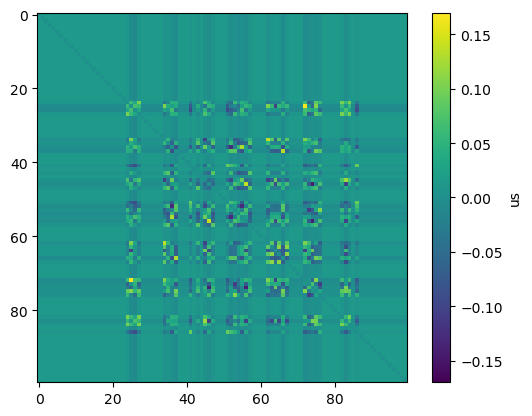

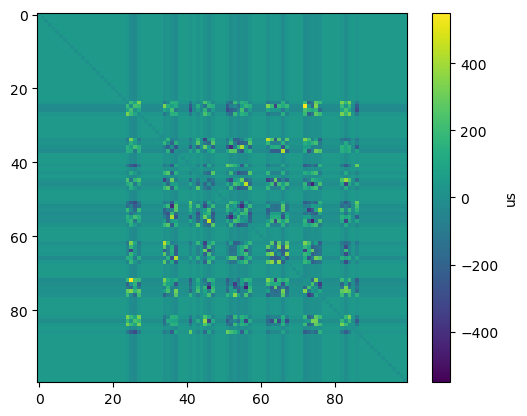

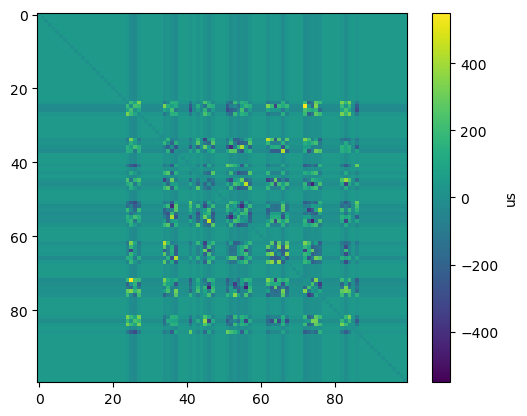

In [196]:
dl = DataLoader()
data = dl.load_csv("../data/HNN_W_matrix_origin.csv")

print(data.shape)
print(np.max(data),np.min(data))

cond_min,cond_max,cond_reference = 0,1100,550
cond_range = cond_max-cond_reference
weight_min,weight_max = -0.17,0.17
target_cond = data/weight_max*cond_range
plot_cond(data,vmin=weight_min,vmax=weight_max)
plot_cond(target_cond,vmin=-cond_range,vmax=cond_range)
plot_cond(target_cond.T,vmin=-cond_range,vmax=cond_range)

In [197]:
tg_map = np.array([1.5,1.55,1.6,1.65,1.7,1.75,1.8])
cond_map = np.array([350,390,450,490,550,590,650])
slope,intercept = np.polyfit(cond_map,tg_map, 1)

66.36581030186794
32.914071875088574


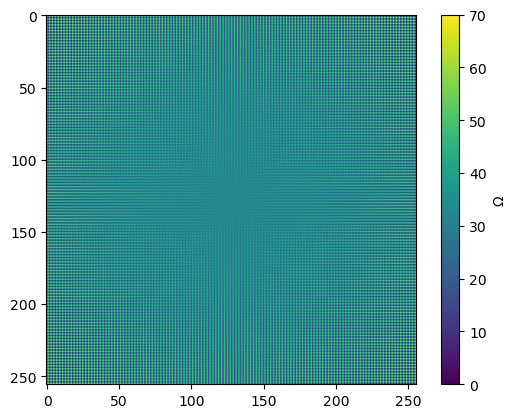

In [201]:
good_device = np.load("../data/good_point_100_100_1_4.npy")
# good_device[1][2]=7
# good_device[1][3]=9
r_out = np.load("../data/r_out_r_wire/chip_1_4_col_r_out_0_50_56_times=2.npy")
r_w_col = np.load("../data/r_out_r_wire/chip_1_4_col_r_wire_0_50_56_times=2.npy")
r_w_row = np.load("../data/r_out_r_wire/chip_1_4_row_r_wire_0_50_56.npy")
r_w_crossbar = np.zeros((256,256))
for row in range(256):
    for col in range(256):
        r_w_crossbar[row,col] = (255-row)*r_w_col[col] if col%2==0 else row*r_w_col[col]
        r_w_crossbar[row,col] += (255-col)*r_w_row[row] if row%2==1 else col*r_w_row[row]

print(np.max(r_w_crossbar))
print(r_w_crossbar[255,0])
plot_cond(r_w_crossbar,vmin=0,vmax=70,label="Ω")

# 2.写权重

In [ ]:
chip.ps.receive_packet(4096)

In [181]:

print(good_device[1])

[  3   5   9  10  11  12  13  14  17  19  21  23  24  25  26  27  30  31
  32  33  34  35  36  37  38  40  41  42  43  44  45  47  49  50  51  52
  53  56  57  58  60  61  63  64  65  66  67  68  70  72  73  77  78  80
  81  82  83  85  86  88  91  92  93  95  96  97  99 100 104 105 106 107
 108 109 110 111 113 114 116 120 121 122 123 124 131 136 137 143 144 169
 181 228 230 232 234 235 239 240 251 255]


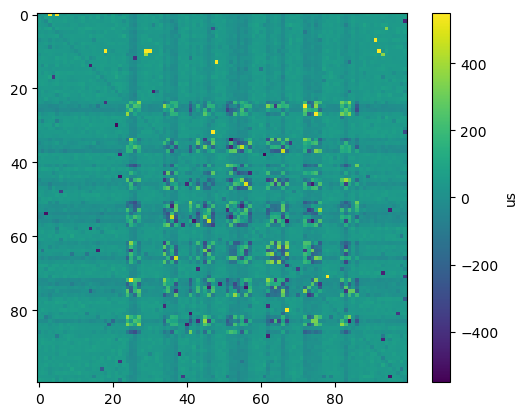

0 reset: 16 set 139


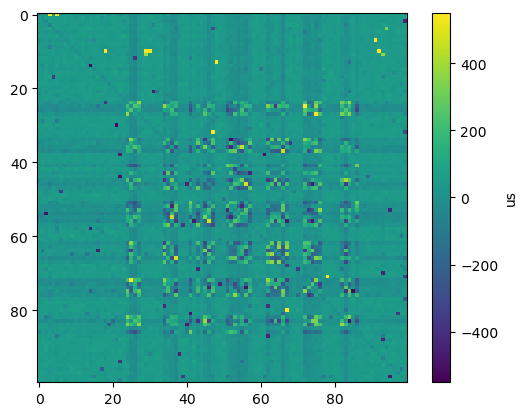

1 reset: 15 set 143


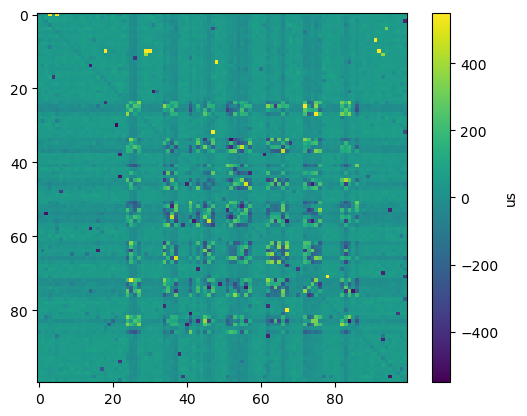

2 reset: 15 set 142


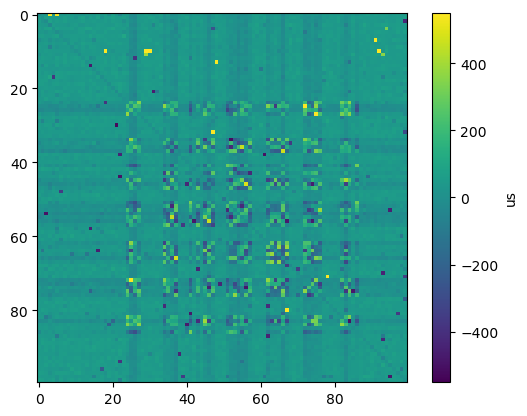

3 reset: 15 set 141


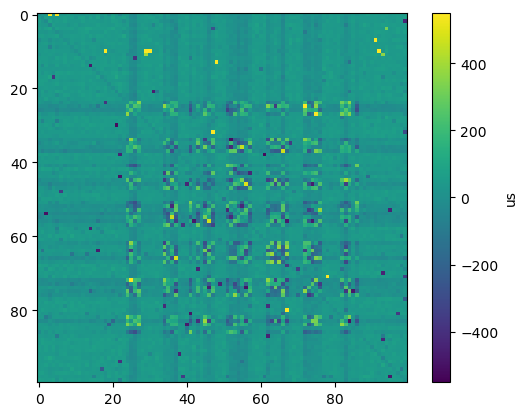

4 reset: 15 set 141


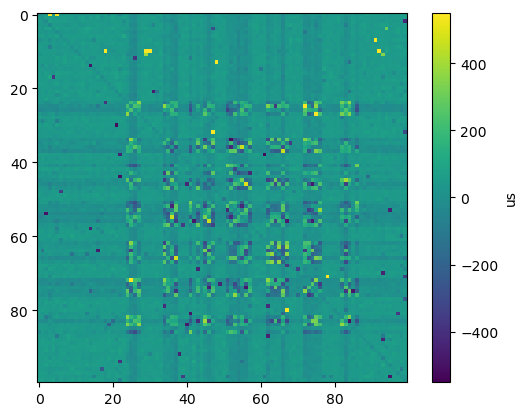

5 reset: 15 set 143


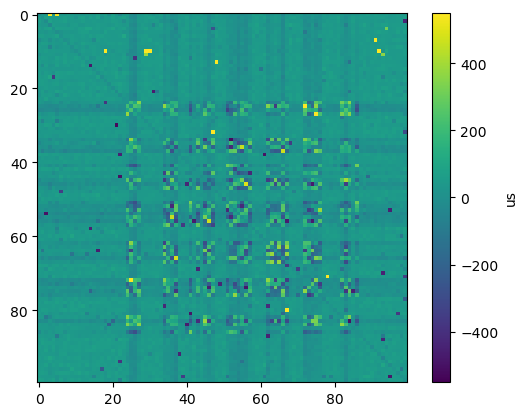

6 reset: 15 set 140


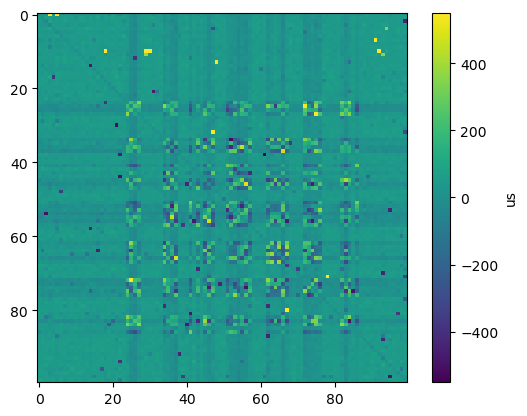

7 reset: 15 set 141


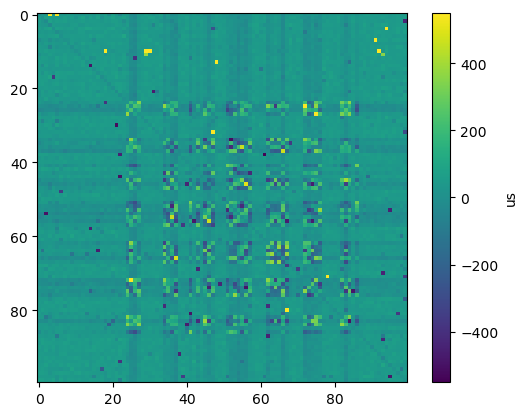

8 reset: 15 set 140


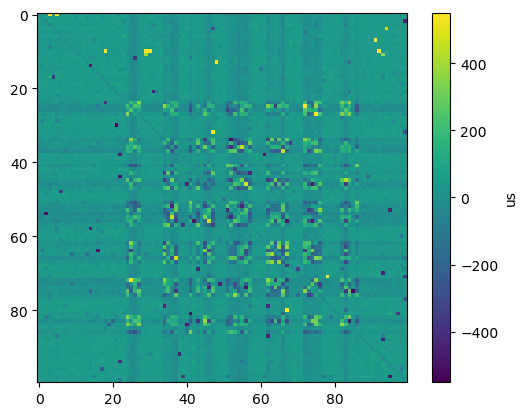

9 reset: 18 set 142


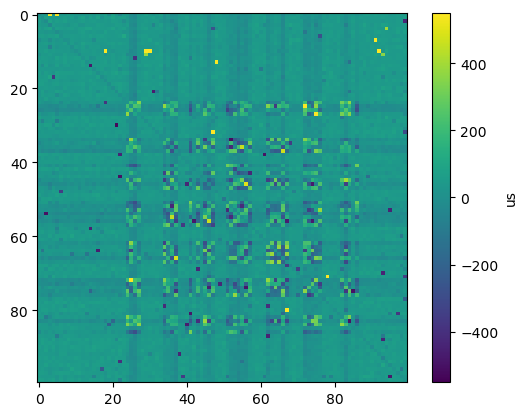

10 reset: 16 set 145


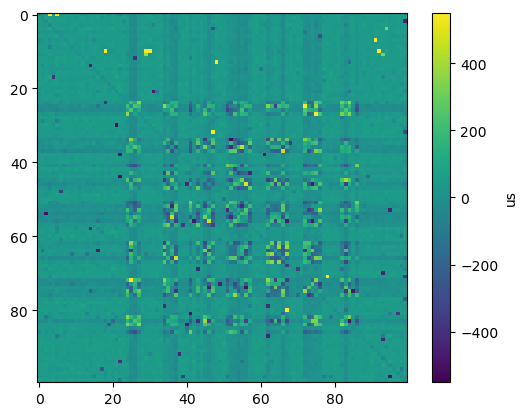

11 reset: 16 set 146


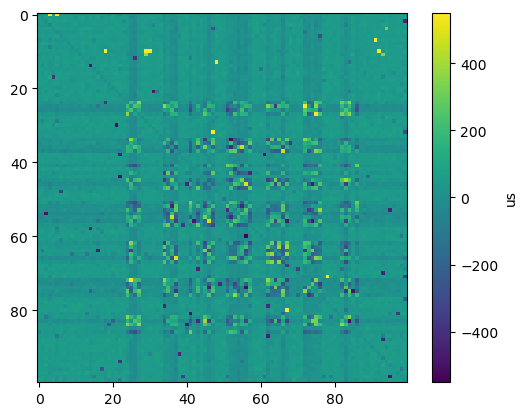

12 reset: 15 set 145


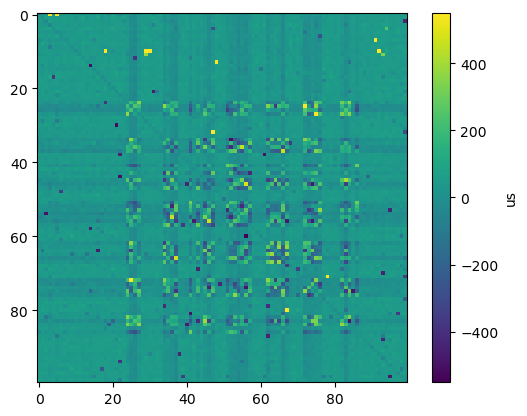

13 reset: 15 set 147


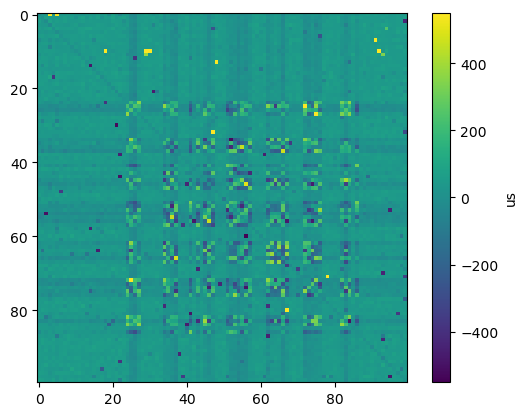

14 reset: 15 set 143


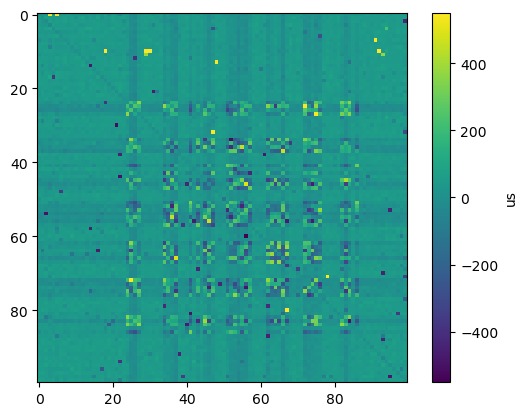

15 reset: 15 set 142


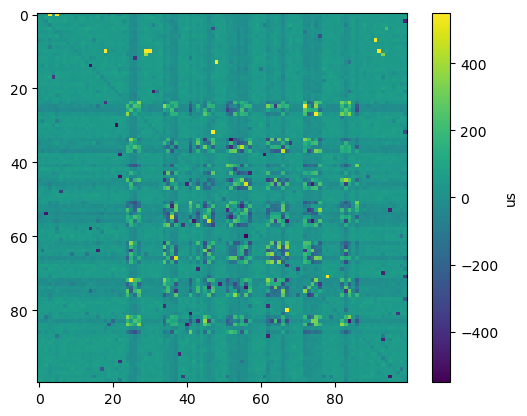

16 reset: 15 set 142


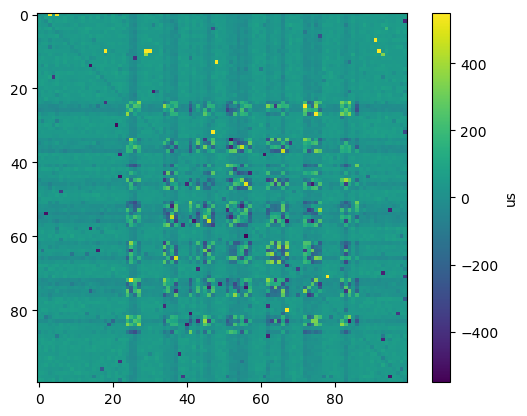

17 reset: 15 set 145


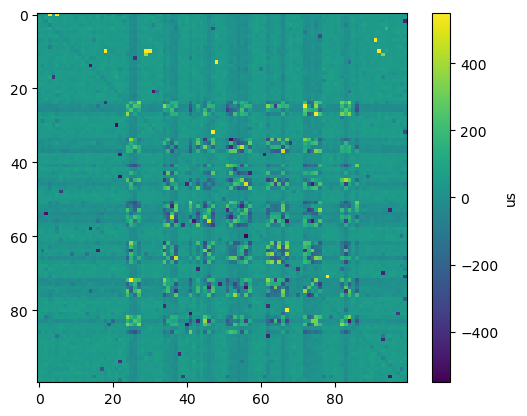

18 reset: 15 set 143


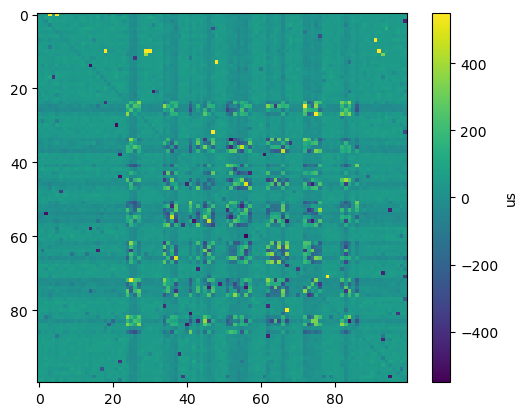

19 reset: 15 set 142


In [220]:
threshold = 60

set_v,reset_v = 1,1.5
reset_pulse_width,set_pulse_width = 100e-6,1000e-6
need_read = np.zeros((256,256),dtype=bool)
target = np.ones((256,256))

pos = np.ix_(good_device[0], good_device[1])


target[pos] = (target_cond + cond_reference).T
tg_v = target*slope+intercept-0.2
need_read[pos] = True

for k in range(1):
    # set_v = set_v+0.1
    # set_pulse_width = set_pulse_width+10e-6*k
    # reset_pulse_width = reset_pulse_width+10e-6*k
    # reset_v = reset_v+0.05
    # tg_v = target*slope+intercept+k*0.05

    for i in range(20):
        voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
        voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
        r = chip.voltage_to_resistance(voltage=voltage-voltage_base)*1e3
        r-=r_w_crossbar
        cond = 1/r*1e6
        plot_cond(cond[pos]-cond_reference,vmin=-cond_range,vmax=cond_range)

        condition_reset = (cond > (target+threshold)) & need_read
        condition_set = (cond < (target-threshold)) & need_read
        print(i,"reset:",np.sum(condition_reset),"set",np.sum(condition_set))

        if i>0:
            # reset_pulse_width = reset_pulse_width+10e-6*i
            # reset_v = reset_v+0.2
            # set_v = set_v+0.05
            # set_pulse_width = set_pulse_width+10e-6*i
            # set_v = set_v+0.05
            # if i<5:
            #     tg_v[condition_reset] -= 0.04
            #     tg_v[condition_set] += 0.04
            # elif i<10:
            #     tg_v[condition_reset] -= 0.02
            #     tg_v[condition_set] += 0.02
            # else:
            tg_v[condition_reset] -= 0.02
            tg_v[condition_set] += 0.02

        tg_v.clip(0,3,out=tg_v)

        chip.write_point2(crossbar=condition_reset,write_voltage=reset_v,tg=5,pulse_width=reset_pulse_width,set_device=False)
        chip.write_point2(crossbar=condition_reset,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width,set_device=True)
        # # # chip.ps.set_time_out(100)
        chip.write_point2(crossbar=condition_set,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width,set_device=True)


# 3.测试读出来的权重推理效果

In [ ]:
print(good_device[0],good_device[1])

In [ ]:
chip.set_chip_sel(19)
chip.adc.set_gap(adc_cs_gap=80,adc_first_gap=20,adc_last_gap=10)
chip.clk_manager.set_cyc(10, 100)
voltage_base_point_row = chip.read_point2(crossbar=np.ones((256,256)),read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
# voltage_point_row = chip.read_point2(crossbar=np.ones((256,256)),read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond_sub_base_row = chip.voltage_to_cond(voltage=voltage_base_point_row)
plot_cond(cond_sub_base_row,title="cond_point_sub_base_row")

In [ ]:
cond=np.load("./data/hnn/cond_sub_base_20250416.npy",)
cond = cond -cond_reference

W = cond/cond_range*0.17

# W.clip(max=0.12,out=W)
print(np.min(W))
# plot_cond(cond,vmin=-cond_range,vmax=cond_range)
plot_cond(W,vmin=-0.17,vmax=0.17,label="weight_value")
plot_cond(target_cond,vmin=-cond_range,vmax=cond_range,label="weight_value")
# plot_cond(W,vmin=-0.17,vmax=0.17,label="weight_value")
plot_cond(data,vmin=-0.17,vmax=0.17,label="weight_value")
a= data-W
plot_cond(data-W,vmin=-0.03,vmax=0.03,label="weight_value")

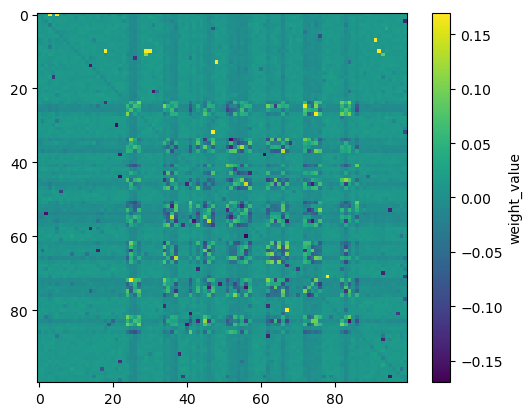

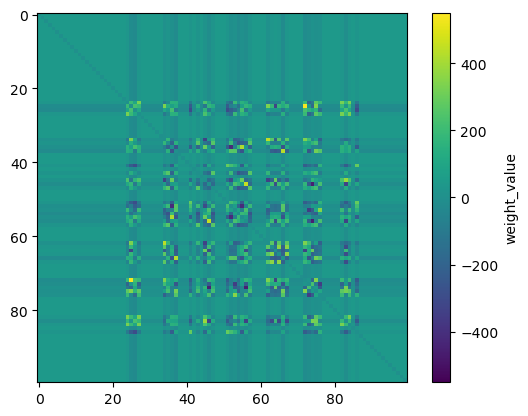

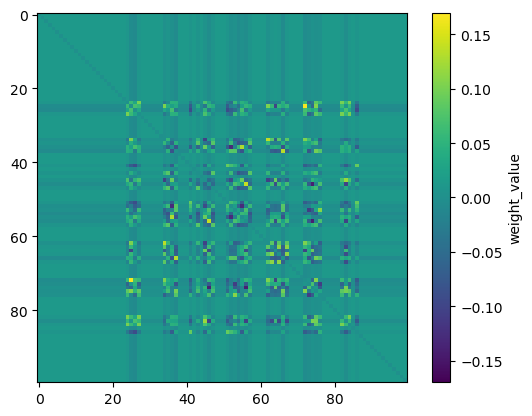

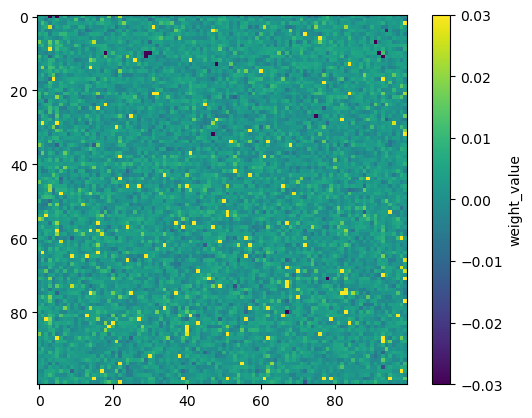

In [230]:
pos = np.ix_(good_device[0], good_device[1])
need_read = np.zeros((256,256),dtype=bool)
need_read[pos] = True
# chip.set_chip_sel(19)
voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)[pos]
# np.save("./data/hnn/cond_sub_base_20250422.npy",cond)
cond = cond -cond_reference
subcond = target_cond-cond
# plt.figure()
# plt.hist(subcond.flatten(),range=(-100,100),bins=400)
# plt.xlabel("uS")
# plt.ylabel("Frequency")
# # plt.xlabel("uS")
# plt.show()
W = cond/cond_range*0.17


# plot_cond(cond,vmin=-cond_range,vmax=cond_range)
plot_cond(W,vmin=-0.17,vmax=0.17,label="weight_value")
plot_cond(target_cond,vmin=-cond_range,vmax=cond_range,label="weight_value")
# plot_cond(W,vmin=-0.17,vmax=0.17,label="weight_value")
plot_cond(data,vmin=-0.17,vmax=0.17,label="weight_value")
b=data-W
plot_cond(data-W,vmin=-0.03,vmax=0.03,label="weight_value")

np.save("../data/hnn/cond_sub.npy",cond)
subcond = target_cond-cond
# plt.figure()
# # plt.hist(b,range=(-200,200))
# # plt.hist(subcond, bins=30, range=(-200,200),color='blue', alpha=0.7, edgecolor='black')  # bins表示直方图的柱数

# # 添加标题和标签
# plt.title("Histogram Example")
# plt.xlabel("Value")
# plt.ylabel("Frequency")

In [ ]:
plot_cond(a-b,vmin=-0.03,vmax=0.03,label="weight_value")

In [ ]:
cond_20250411 = np.load("./data/hnn/cond_sub_base_20250410.npy")
W_20250411 = (cond_20250411-cond_reference)/cond_range*0.17
plot_cond(W,vmin=-0.17,vmax=0.17)
plot_cond(data-W_20250411,vmin=-0.17,vmax=0.17)
plot_cond((data-W_20250411)/data,vmin=-1,vmax=1)

cond_20250411 = np.load("./data/hnn/cond_sub_base_20250411.npy")
W_20250411 = (cond_20250411-cond_reference)/cond_range*0.17
plot_cond(W,vmin=-0.17,vmax=0.17)
plot_cond(data-W_20250411,vmin=-0.17,vmax=0.17)
plot_cond((data-W_20250411)/data,vmin=-1,vmax=1)

In [ ]:
steps=10

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from skimage.transform import resize
# -----------------------------
# 可调参数：网络总神经元数量（必须为完全平方数，如100、400、784等）
net_size = 100  # 例如 100 表示 10×10
num_imgs = 5
side = int(np.sqrt(net_size))  # 图像边长

# -----------------------------
# 1. 加载 MNIST 数据，选取数字 0～9 各一张图
(train_images, train_labels), _ = mnist.load_data()

selected_patterns = []
for digit in range(num_imgs):
    idx = np.where(train_labels == digit)[0][0]
    img = train_images[idx]
    selected_patterns.append(img)

# -----------------------------
# 2. 定义预处理函数：缩放 + 二值化
def preprocess_image(img, side, threshold=128):
    """
    缩放原始图像到 side x side，并二值化（像素值 > threshold 记为 +1，其它记为 -1）
    """
    # 缩放图像到 side x side（返回浮点型，值在0-1之间）
    img_resized = resize(img, (side, side), anti_aliasing=True)
    # 还原到0-255范围
    img_resized = img_resized * 255
    # 二值化
    bin_img = np.where(img_resized > threshold, 1, -1)
    return bin_img


# 对选取的图像进行预处理
processed_patterns = [preprocess_image(p, side) for p in selected_patterns]


def hopfield_recall_sync(state, W, steps=10000):
    """
    state: 初始状态（side x side，取值 +1 或 -1）
    W: 训练好的权重矩阵
    steps: 最大更新次数
    返回: 收敛后的状态（side x side）

    采用同步更新：每一步计算所有神经元的新状态，然后同时更新
    """
    state_flat = state.flatten()
    print(state_flat.shape)
    for _ in range(steps):
        # 同步计算所有神经元的净输入并更新状态
        # new_state = np.where(forward(state_flat) >= 0, 1, -1)
        new_state = np.where(np.dot(W, state_flat) >= 0, 1, -1)
        # 如果新状态与旧状态相同，则认为已收敛，退出循环
        if np.array_equal(new_state, state_flat):
            break
        state_flat = new_state
    return state_flat.reshape((state.shape))

# -----------------------------
# 5. 定义损坏函数（随机翻转像素）
def damage_pattern(pattern, damage_rate=0.3):
    """
    随机翻转一定比例 (damage_rate) 的像素
    """
    damaged = pattern.copy().flatten()
    N = damaged.size
    num_flip = int(damage_rate * N)
    flip_indices = np.random.choice(N, num_flip, replace=False)
    damaged[flip_indices] *= -1
    return damaged.reshape((side, side))

# -----------------------------
# 6. 对每个数字测试：破坏后用 Hopfield 网络回忆
recovered_patterns = []
damaged_patterns = []
damage_rate = 0.1 # 例如翻转 30% 像素

for p in processed_patterns:
    damaged = damage_pattern(p, damage_rate)
    recovered = hopfield_recall_sync(damaged, W, steps=steps)
    damaged_patterns.append(damaged)
    recovered_patterns.append(recovered)

fig, axes = plt.subplots(3, num_imgs, figsize=(20, 6))
for i in range(num_imgs):
    # 第一行：原始图像
    axes[0, i].imshow(processed_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].set_title(f"{i}")
    axes[0, i].axis('off')

    # 第二行：损坏图像
    axes[1, i].imshow(damaged_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].set_title("Damaged")
    axes[1, i].axis('off')

    # 第三行：回忆结果
    axes[2, i].imshow(recovered_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[2, i].set_title("Recovered")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()


# 4.片上推理测试

In [ ]:
good_device = np.load("./data/good_point_100_100_1_4.npy")
r_out = np.load("./data/chip_1_4_col_r_out.npy")
r_w = np.load("./data/chip_1_4_col_r_wire.npy")
# 偶数行向下输出，线阻在下面, 奇数在上面

state_flat = np.load("./data/image0.npy").reshape(1,100)


# 从行给信号
row_index = good_device[0][np.where(state_flat > 0)[1]]
col_index = good_device[1]
row_nums = len(row_index)
print(row_nums)

min_row,max_row = np.min(row_index),np.max(row_index)-10
print(min_row,max_row)
col_rw = np.array([(256-max_row)*r_w[i] if i%2==0 else (min_row)*r_w[i] for i in col_index])

min_col,max_col = np.min(col_index),np.max(col_index)
row_rw = np.array([(256-max_col)*r_w[i] if i%2==0 else (min_col)*r_w[i] for i in col_index])

gain = 1 if row_nums<=10 else 3
from_row = True
# -------------------------------------
voltage_base = chip.read_chunk_parallel2(row_index=[row_index],col_index=[col_index],
                                            read_voltage=0,tg=5,gain=gain,from_row=from_row,out_type=0,compute=True
                                        ,tia_split=[0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3]
                                        )
voltage = chip.read_chunk_parallel2(row_index=[row_index],col_index=[col_index],
                                    read_voltage=0.1,tg=5,gain=gain, from_row=from_row,out_type=0,compute=True
                                    ,tia_split=[0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3]
                                    )
parallel_r = chip.voltage_to_resistance(voltage = voltage-voltage_base)[:,col_index]*1e3 - r_out[col_index] - col_rw - r_w[col_index]*(row_nums*0.875)
print(parallel_r.shape)
cond0 = 1/parallel_r*1e6
# 单位A
parallel_i = 1/parallel_r - cond_reference*1e-6*row_nums
parallel_value = parallel_i/(cond_range*1e-6)*weight_max
# -------------------------------------
need_read = np.zeros((256,256),dtype=bool)
weight_pos = np.ix_(row_index, col_index)
need_read[weight_pos] = True

voltage_base=chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=gain,from_row=from_row,out_type=0)
voltage=chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=gain,from_row=from_row,out_type=0)
not_parallel_r = chip.voltage_to_resistance(voltage = voltage-voltage_base)[:,col_index]*1e3 - r_out[col_index] - col_rw - r_w[col_index]*(row_nums*0.875)
print(not_parallel_r.shape)
# 单位A
cond1 = 1/not_parallel_r*1e6
not_parallel_i = 1/not_parallel_r - cond_reference*1e-6*row_nums
not_parallel_value = not_parallel_i/(cond_range*1e-6)*weight_max
# -------------------------------------
need_read = np.zeros((256,256),dtype=bool)
weight_pos = np.ix_(row_index, col_index)
need_read[weight_pos] = True
voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=False,out_type=0)
voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=False,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)[weight_pos]
cond = np.sum(cond,axis=0)
# 单位A
real_i =cond*1e-6 - cond_reference*1e-6*row_nums
print(real_i.shape)
print(cond_reference*row_nums)
real_value = real_i/(cond_range*1e-6)*weight_max

for i in range(100):
    print(col_index[i],cond[i],cond[i]-cond0[0,i],cond[i]-cond1[0,i])
    # print(col_index[i],real_value[i]-not_parallel_value[0,i],real_value[i])
    # print((256-max_row)*r_w[i] if col_index[i]%2==0 else min_row*r_w[i])
    # print(real_i[i],parallel_i[0,i],not_parallel_i[0,i])
    # print(real_value[i],parallel_value[0,i],not_parallel_value[0,i])
    # print(real_value[i]-parallel_value[0,i],real_value[i]-not_parallel_value[0,i])
    # print()


In [188]:
print(np.diff(good_device[0]))
print(good_device[0],good_device[1])

[ 1 22  1  1  3  3  1  1  1  2  2  1  2  2  3  1  2  1  1  1  1  1  4  4
  1  1  2  1  1  1  3  2  4  1  1  1  1  1  1  1  1  1  2  1  2  1  2  1
  1  1  1  1  1  2  2  1  1  1  1  1  4  1  1  3  1  1  1  1  2  1  1  1
  2  3  1  3  1  1  2  4  1  1  1  1  1  1  3  1  2 54  2  1  1  1  1  1
  1 25  1]
[ 10  11  33  34  35  38  41  42  43  44  46  48  49  51  53  56  57  59
  60  61  62  63  64  68  72  73  74  76  77  78  79  82  84  88  89  90
  91  92  93  94  95  96  97  99 100 102 103 105 106 107 108 109 110 111
 113 115 116 117 118 119 120 124 125 126 129 130 131 132 133 135 136 137
 138 140 143 144 147 148 149 151 155 156 157 158 159 160 161 164 165 167
 221 223 224 225 226 227 228 229 254 255] [  3   5   9  10  11  12  13  14  17  19  21  23  24  25  26  27  30  31
  32  33  34  35  36  37  38  40  41  42  43  44  45  47  49  50  51  52
  53  56  57  58  60  61  63  64  65  66  67  68  70  72  73  77  78  80
  81  82  83  85  86  88  91  92  93  95  96  97  99 100 104 105 106 10

In [222]:
# good_device = np.load("../data/good_point_100_100_1_4.npy")
# good_device[1][2]=7
# good_device[1][3]=9
r_out = np.load("../data/chip_1_4_col_r_out.npy")
r_w = np.load("../data/chip_1_4_col_r_wire.npy")
def forward_unsigned_from_row(row_index,col_index,forward_type=1):
    """
        从行给信号进行推理
    """
    col_nums = len(col_index)
    row_nums = len(row_index)
    from_row = True
    if col_nums <= 0:
        return np.zeros((len(row_index),1))
    
    min_row,max_row = np.min(row_index),np.max(row_index)
    row_rw = np.array([(256-max_row)*r_w[i] if i%2==0 else (min_row)*r_w[i] for i in col_index])
    gain = 1 if row_nums<=10 else 3
    if forward_type==1:
        # -------------------------------------
        voltage_base = chip.read_chunk_parallel2(row_index=[row_index],col_index=[col_index],
                                                    read_voltage=0,tg=5,gain=gain,from_row=from_row,out_type=0,compute=True
                                                # ,tia_split=[0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3]
                                                ,tia_split=[0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,]
                                                # ,tia_split=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,]
                                                )
        voltage = chip.read_chunk_parallel2(row_index=[row_index],col_index=[col_index],
                                            read_voltage=0.1,tg=5,gain=gain, from_row=from_row,out_type=0,compute=True
                                            # ,tia_split=[0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3]
                                            ,tia_split=[0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,]
                                            # ,tia_split=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,]
                                            )
        parallel_r = chip.voltage_to_resistance(voltage = voltage-voltage_base)[:,col_index]*1e3 - r_out[col_index] - row_rw - r_w[col_index]*(row_nums**0.875)
        # 单位A
        parallel_i = 1/parallel_r - cond_reference*1e-6*row_nums
        parallel_value = parallel_i/(cond_range*1e-6)*weight_max
        return parallel_value.flatten()
    elif forward_type==2:
        need_read = np.zeros((256,256),dtype=bool)
        weight_pos = np.ix_(row_index, col_index)
        need_read[weight_pos] = True

        voltage_base=chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=gain,from_row=from_row,out_type=0)
        voltage=chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=gain,from_row=from_row,out_type=0)
        not_parallel_r = chip.voltage_to_resistance(voltage = voltage-voltage_base)[:,col_index]*1e3 - r_out[col_index] - row_rw - r_w[col_index]*(row_nums**0.875)
        # 单位A
        not_parallel_i = 1/not_parallel_r - cond_reference*1e-6*row_nums
        not_parallel_value = not_parallel_i/(cond_range*1e-6)*weight_max
        return not_parallel_value.flatten()
    elif forward_type==3:
        # need_read = np.zeros((256,256),dtype=bool)
        # weight_pos = np.ix_(row_index, col_index)
        # need_read[weight_pos] = True
        # voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=from_row,out_type=0)
        # voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=from_row,out_type=0)
        # cond = chip.voltage_to_cond(voltage=voltage-voltage_base)[weight_pos]-cond_reference
        # cond =np.sum(cond,axis=0)

        # return (cond/cond_range*weight_max).flatten()
        need_read = np.zeros((256,256),dtype=bool)
        weight_pos = np.ix_(row_index, col_index)
        need_read[weight_pos] = True
        voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=from_row,out_type=0)
        voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=from_row,out_type=0)
        cond = chip.voltage_to_cond(voltage=voltage-voltage_base)[weight_pos]

        # 单位A
        real_i =np.sum(cond,axis=0) - cond_reference*row_nums
        real_value = real_i/(cond_range)*weight_max
        return real_value.flatten()
    

In [226]:
# 两个100个元素的列表

def forward_from_row(state_flat:np.ndarray):
    """
        state_flat:为1*100的np数组
        split_type = 0,就是采用
    """
    state_flat_new = state_flat.reshape(1,100)
    interval = 50
    forward_type = 2

    col_index = good_device[1]
    
    row_index = good_device[0][np.where(state_flat_new > 0)[1]]
    row_nums = len(row_index)
    steps = math.ceil(row_nums/interval)
    value_pos = np.zeros((len(col_index)))
    for i in range(steps):
        # print(i*interval,min((i+1)*interval,row_nums))
        value_pos += forward_unsigned_from_row(row_index[i*interval:min((i+1)*interval,row_nums)],col_index,forward_type=forward_type)
    

    row_index = good_device[0][np.where(state_flat_new < 0)[1]]
    row_nums = len(row_index)
    steps = math.ceil(row_nums/interval)
    value_neg = np.zeros((len(col_index)))
    for i in range(steps):
        # print(i*interval,min((i+1)*interval,row_nums))
        value_neg += forward_unsigned_from_row(row_index[i*interval:min((i+1)*interval,row_nums)],col_index,forward_type=forward_type)

    return value_pos-value_neg

In [227]:
steps = 10

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from skimage.transform import resize

(100,)
(100,)
(100,)
(100,)
(100,)


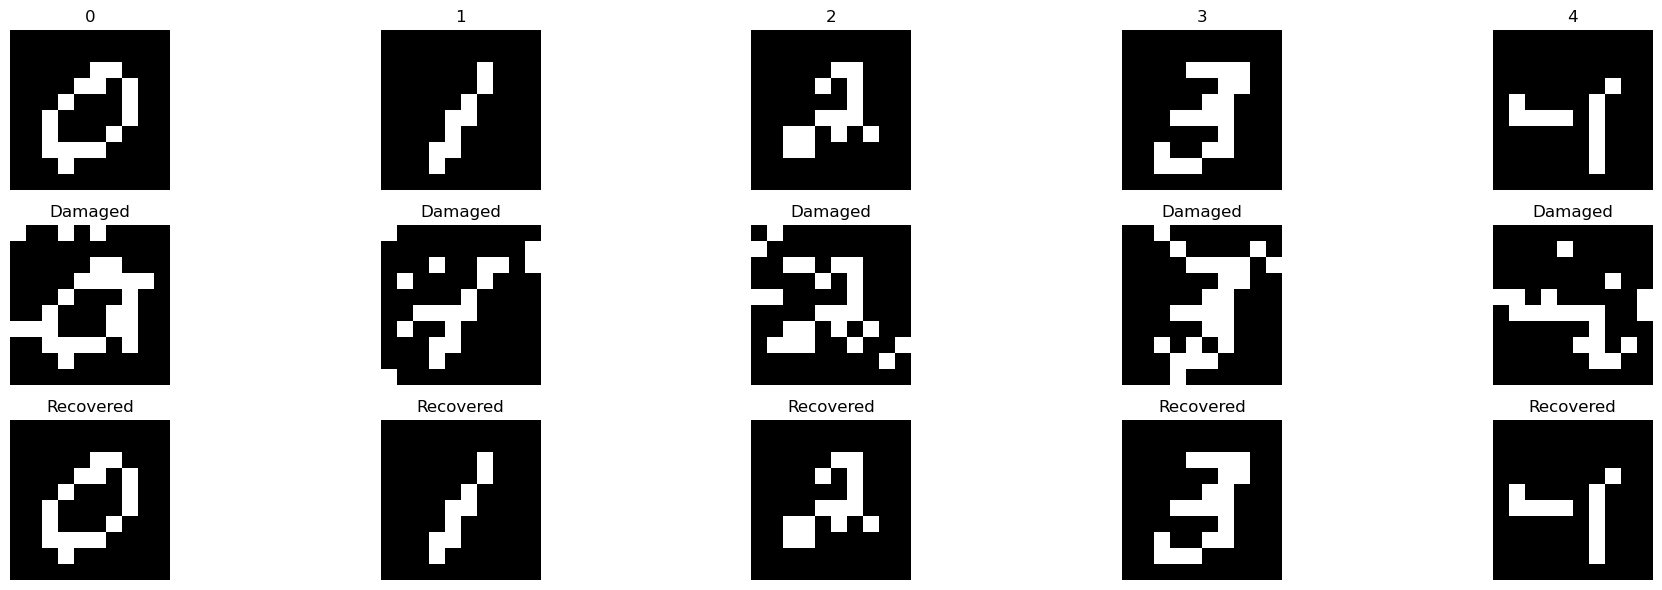

In [229]:
net_size = 100  # 例如 100 表示 10×10
num_imgs = 5
side = int(np.sqrt(net_size))  # 图像边长

# -----------------------------
# 1. 加载 MNIST 数据，选取数字 0～9 各一张图
(train_images, train_labels), _ = mnist.load_data()

selected_patterns = []
for digit in range(num_imgs):
    idx = np.where(train_labels == digit)[0][0]
    img = train_images[idx]
    selected_patterns.append(img)


# 2. 定义预处理函数：缩放 + 二值化
def preprocess_image(img, side, threshold=128):
    """
    缩放原始图像到 side x side，并二值化（像素值 > threshold 记为 +1，其它记为 -1）
    """
    # 缩放图像到 side x side（返回浮点型，值在0-1之间）
    img_resized = resize(img, (side, side), anti_aliasing=True)
    # 还原到0-255范围
    img_resized = img_resized * 255
    # 二值化
    bin_img = np.where(img_resized > threshold, 1, -1)
    return bin_img

# 对选取的图像进行预处理
processed_patterns = [preprocess_image(p, side) for p in selected_patterns]

def hopfield_recall_sync(state, W, steps=10000):
    """
    state: 初始状态（side x side，取值 +1 或 -1）
    W: 训练好的权重矩阵
    steps: 最大更新次数
    返回: 收敛后的状态（side x side）

    采用同步更新：每一步计算所有神经元的新状态，然后同时更新
    """
    state_flat = state.flatten()
    print(state_flat.shape)
    for _ in range(steps):
        # 同步计算所有神经元的净输入并更新状态
        new_state = np.where(forward_from_row(state_flat) >= 0, 1, -1)
        # new_state = np.where(np.dot(W, state_flat) >= 0, 1, -1)
        # 如果新状态与旧状态相同，则认为已收敛，退出循环
        if np.array_equal(new_state, state_flat):
            break
        state_flat = new_state
    return state_flat.reshape((state.shape))

# 5. 定义损坏函数（随机翻转像素）
def damage_pattern(pattern, damage_rate=0.3):
    """
    随机翻转一定比例 (damage_rate) 的像素
    """
    damaged = pattern.copy().flatten()
    N = damaged.size
    num_flip = int(damage_rate * N)
    flip_indices = np.random.choice(N, num_flip, replace=False)
    damaged[flip_indices] *= -1
    return damaged.reshape((side, side))

np.save("../data/hnn/processed_patterns.npy",processed_patterns)

# -----------------------------
# 6. 对每个数字测试：破坏后用 Hopfield 网络回忆
recovered_patterns = []
damaged_patterns = []
damage_rate = 0.1 # 例如翻转 30% 像素

for p in processed_patterns:
    damaged = damage_pattern(p, damage_rate)
    recovered = hopfield_recall_sync(damaged, W, steps=steps)
    damaged_patterns.append(damaged)
    recovered_patterns.append(recovered)

fig, axes = plt.subplots(3, num_imgs, figsize=(20, 6))
for i in range(num_imgs):
    # 第一行：原始图像
    axes[0, i].imshow(processed_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].set_title(f"{i}")
    axes[0, i].axis('off')

    # 第二行：损坏图像
    axes[1, i].imshow(damaged_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].set_title("Damaged")
    axes[1, i].axis('off')

    # 第三行：回忆结果
    axes[2, i].imshow(recovered_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[2, i].set_title("Recovered")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
print(len(processed_patterns))
print(processed_patterns[0].shape)